<a href="https://colab.research.google.com/github/Kavyapm01/GAN-Synthetic-Image-Generation-and-Augmentation/blob/main/cgan.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Step 1: Env setup (run this cell)
!nvidia-smi

# Install required packages
!pip install --upgrade pip
!pip install torch torchvision --index-url https://download.pytorch.org/whl/cu118 --quiet
!pip install opendatasets --upgrade --quiet
!pip install tqdm pillow matplotlib scikit-image --quiet

# (Optional) show python & torch info
import sys, torch
print("Python:", sys.version)
print("Torch:", torch.__version__, "CUDA available:", torch.cuda.is_available())


Wed Nov  5 16:10:40 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   51C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
import opendatasets as od
import os, shutil, random

# Download dataset
dataset_url = "https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia"
od.download(dataset_url)

# Base original dataset path
base_path = "/content/chest-xray-pneumonia/chest_xray"

# Output reduced dataset path
reduced_path = "/content/dataset_300"
os.makedirs(reduced_path, exist_ok=True)

# Create target structure for CycleGAN (A = NORMAL, B = PNEUMONIA)
trainA = os.path.join(reduced_path, "trainA")
trainB = os.path.join(reduced_path, "trainB")
testA = os.path.join(reduced_path, "testA")
testB = os.path.join(reduced_path, "testB")

os.makedirs(trainA, exist_ok=True)
os.makedirs(trainB, exist_ok=True)
os.makedirs(testA, exist_ok=True)
os.makedirs(testB, exist_ok=True)

# Function to copy N random images
def copy_random_images(source_folder, dest_folder, n):
    images = os.listdir(source_folder)
    random.shuffle(images)
    selected = images[:n]
    for img in selected:
        shutil.copy(os.path.join(source_folder, img), dest_folder)

# Copy 300 NORMAL -> trainA
copy_random_images(os.path.join(base_path, "train/NORMAL"), trainA, 300)

# Copy 300 PNEUMONIA -> trainB
copy_random_images(os.path.join(base_path, "train/PNEUMONIA"), trainB, 300)

# Copy 50 NORMAL -> testA
copy_random_images(os.path.join(base_path, "test/NORMAL"), testA, 50)

# Copy 50 PNEUMONIA -> testB
copy_random_images(os.path.join(base_path, "test/PNEUMONIA"), testB, 50)

print("✅ Reduced dataset created at:", reduced_path)
print("TrainA (NORMAL):", len(os.listdir(trainA)))
print("TrainB (PNEUMONIA):", len(os.listdir(trainB)))
print("TestA:", len(os.listdir(testA)))
print("TestB:", len(os.listdir(testB)))


Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: pujark
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia


100%|██████████| 2.29G/2.29G [00:20<00:00, 118MB/s]



✅ Reduced dataset created at: /content/dataset_300
TrainA (NORMAL): 300
TrainB (PNEUMONIA): 300
TestA: 50
TestB: 50


In [ ]:
from torch.utils.data import Dataset, DataLoader
from PIL import Image
from torchvision import transforms
import os
import random

# Path of reduced dataset we created
data_root = "/content/dataset_300"

# Image transform (128x128 for faster training)
transform = transforms.Compose([
    transforms.Resize((128,128)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

class UnpairedDataset(Dataset):
    def __init__(self, dir_A, dir_B, transform=None):
        self.A_images = [os.path.join(dir_A, f) for f in os.listdir(dir_A)]
        self.B_images = [os.path.join(dir_B, f) for f in os.listdir(dir_B)]
        self.transform = transform

    def __len__(self):
        return max(len(self.A_images), len(self.B_images))

    def __getitem__(self, index):
        img_A = Image.open(self.A_images[index % len(self.A_images)]).convert("L")
        img_B = Image.open(self.B_images[random.randint(0, len(self.B_images)-1)]).convert("L")

        if self.transform:
            img_A = self.transform(img_A)
            img_B = self.transform(img_B)

        return img_A, img_B

# A = NORMAL, B = PNEUMONIA
trainA = os.path.join(data_root, "trainA")
trainB = os.path.join(data_root, "trainB")

dataset = UnpairedDataset(trainA, trainB, transform)
train_loader = DataLoader(dataset, batch_size=4, shuffle=True)

print("✅ Dataset & DataLoader Ready!")
print("Total training samples:", len(dataset))


✅ Dataset & DataLoader Ready!
Total training samples: 300


In [ ]:
# -----------------------------
# Step 4: Models (grayscale)
# -----------------------------
import torch
import torch.nn as nn

# ResNet block
class ResnetBlock(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.block = nn.Sequential(
            nn.ReflectionPad2d(1),
            nn.Conv2d(dim, dim, kernel_size=3, padding=0, bias=False),
            nn.InstanceNorm2d(dim),
            nn.ReLU(inplace=True),
            nn.ReflectionPad2d(1),
            nn.Conv2d(dim, dim, kernel_size=3, padding=0, bias=False),
            nn.InstanceNorm2d(dim)
        )
    def forward(self, x):
        return x + self.block(x)

# ResNet generator (c7s1-64, d128, d256, R256 x n, u128, u64, c7s1-1)
class ResnetGenerator(nn.Module):
    def __init__(self, in_channels=1, out_channels=1, ngf=64, n_blocks=6):
        super().__init__()
        model = []
        model += [nn.ReflectionPad2d(3),
                  nn.Conv2d(in_channels, ngf, kernel_size=7, padding=0, bias=False),
                  nn.InstanceNorm2d(ngf),
                  nn.ReLU(True)]
        # downsample x2
        model += [
            nn.Conv2d(ngf, ngf * 2, kernel_size=3, stride=2, padding=1, bias=False),
            nn.InstanceNorm2d(ngf * 2),
            nn.ReLU(True),
            nn.Conv2d(ngf * 2, ngf * 4, kernel_size=3, stride=2, padding=1, bias=False),
            nn.InstanceNorm2d(ngf * 4),
            nn.ReLU(True)
        ]
        # resnet blocks
        for _ in range(n_blocks):
            model += [ResnetBlock(ngf * 4)]
        # upsample x2
        model += [
            nn.ConvTranspose2d(ngf * 4, ngf * 2, kernel_size=3, stride=2, padding=1, output_padding=1, bias=False),
            nn.InstanceNorm2d(ngf * 2),
            nn.ReLU(True),
            nn.ConvTranspose2d(ngf * 2, ngf, kernel_size=3, stride=2, padding=1, output_padding=1, bias=False),
            nn.InstanceNorm2d(ngf),
            nn.ReLU(True),
            nn.ReflectionPad2d(3),
            nn.Conv2d(ngf, out_channels, kernel_size=7, padding=0),
            nn.Tanh()
        ]
        self.model = nn.Sequential(*model)
    def forward(self, x):
        return self.model(x)

# PatchGAN discriminator (70x70)
class PatchDiscriminator(nn.Module):
    def __init__(self, in_channels=1, ndf=64):
        super().__init__()
        kw = 4; padw = 1
        sequence = [
            nn.Conv2d(in_channels, ndf, kernel_size=kw, stride=2, padding=padw),
            nn.LeakyReLU(0.2, True)
        ]
        nf_mult = 1
        nf_mult_prev = 1
        for n in range(1, 3):  # add 2 conv layers (ndf->ndf*2->ndf*4)
            nf_mult_prev = nf_mult
            nf_mult = min(2**n, 8)
            sequence += [
                nn.Conv2d(ndf * nf_mult_prev, ndf * nf_mult, kernel_size=kw, stride=2, padding=padw, bias=False),
                nn.InstanceNorm2d(ndf * nf_mult),
                nn.LeakyReLU(0.2, True)
            ]
        nf_mult_prev = nf_mult
        nf_mult = min(2**3, 8)
        sequence += [
            nn.Conv2d(ndf * nf_mult_prev, ndf * nf_mult, kernel_size=kw, stride=1, padding=padw, bias=False),
            nn.InstanceNorm2d(ndf * nf_mult),
            nn.LeakyReLU(0.2, True)
        ]
        sequence += [nn.Conv2d(ndf * nf_mult, 1, kernel_size=kw, stride=1, padding=padw)]
        self.model = nn.Sequential(*sequence)
    def forward(self, x):
        return self.model(x)

# Weight init
def init_weights(net, init_gain=0.02):
    def init_func(m):
        classname = m.__class__.__name__
        if hasattr(m, 'weight') and (classname.find('Conv') != -1 or classname.find('Linear') != -1):
            nn.init.normal_(m.weight.data, 0.0, init_gain)
            if hasattr(m, 'bias') and m.bias is not None:
                nn.init.constant_(m.bias.data, 0.0)
        elif classname.find('InstanceNorm2d') != -1:
            if hasattr(m, 'weight') and m.weight is not None:
                nn.init.normal_(m.weight.data, 1.0, init_gain)
            if hasattr(m, 'bias') and m.bias is not None:
                nn.init.constant_(m.bias.data, 0.0)
    net.apply(init_func)

# instantiate
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
G_AB = ResnetGenerator(1,1,ngf=64,n_blocks=6).to(device)   # Normal -> Pneumonia
G_BA = ResnetGenerator(1,1,ngf=64,n_blocks=6).to(device)   # Pneumonia -> Normal
D_A  = PatchDiscriminator(1).to(device)                    # Discr. for Normal
D_B  = PatchDiscriminator(1).to(device)                    # Discr. for Pneumonia

# init weights
init_weights(G_AB)
init_weights(G_BA)
init_weights(D_A)
init_weights(D_B)

print("✅ Models created and initialized. Device:", device)
print("G_AB params:", sum(p.numel() for p in G_AB.parameters()))


✅ Models created and initialized. Device: cuda
G_AB params: 7821441


In [ ]:
# -----------------------------
# Step 5: Losses, Optimizers, Scheduler, ImagePool
# -----------------------------
import itertools
import torch.nn as nn
import torch.optim as optim
import random

# Training config
num_epochs = 100
decay_epoch = 50   # start LR decay at this epoch (1-based)
lr = 2e-4
beta1 = 0.5

# Losses
criterion_GAN = nn.MSELoss().to(device)     # LSGAN
criterion_cycle = nn.L1Loss().to(device)
criterion_identity = nn.L1Loss().to(device)

# Optimizers (generators share single optimizer)
optimizer_G = optim.Adam(itertools.chain(G_AB.parameters(), G_BA.parameters()), lr=lr, betas=(beta1, 0.999))
optimizer_D_A = optim.Adam(D_A.parameters(), lr=lr, betas=(beta1, 0.999))
optimizer_D_B = optim.Adam(D_B.parameters(), lr=lr, betas=(beta1, 0.999))

# Linear LR decay: lambda returns multiplier for initial LR for a given epoch index (0-based)
def lambda_rule(epoch_idx):
    # epoch_idx is 0-based
    # keep LR constant until decay_epoch (1-based), then linearly decay to 0 at num_epochs
    return 1.0 - max(0, epoch_idx - (decay_epoch - 1)) / float(max(1, num_epochs - decay_epoch + 1))

scheduler_G = optim.lr_scheduler.LambdaLR(optimizer_G, lr_lambda=lambda_rule)
scheduler_D_A = optim.lr_scheduler.LambdaLR(optimizer_D_A, lr_lambda=lambda_rule)
scheduler_D_B = optim.lr_scheduler.LambdaLR(optimizer_D_B, lr_lambda=lambda_rule)

# Image pool for discriminator (stabilizes training)
class ImagePool:
    def __init__(self, max_size=50):
        self.max_size = max_size
        self.images = []

    def query(self, images):
        # images: torch.Tensor batch (B,C,H,W)
        result = []
        for img in images:
            img = img.unsqueeze(0)
            if len(self.images) < self.max_size:
                # fill pool, return current image
                self.images.append(img.clone())
                result.append(img)
            else:
                if random.random() > 0.5:
                    idx = random.randint(0, self.max_size - 1)
                    tmp = self.images[idx].clone()
                    self.images[idx] = img.clone()
                    result.append(tmp)
                else:
                    result.append(img)
        return torch.cat(result, dim=0)

fake_A_pool = ImagePool(max_size=50)
fake_B_pool = ImagePool(max_size=50)

# convenience tensors (created during training with matching shape using ones_like/zeros_like)
print("✅ Losses, optimizers, schedulers and image pools are ready")
print(f"Training for {num_epochs} epochs with LR={lr}, decay starting at epoch {decay_epoch}")


✅ Losses, optimizers, schedulers and image pools are ready
Training for 100 epochs with LR=0.0002, decay starting at epoch 50


In [ ]:
from tqdm import tqdm

for epoch in range(1, num_epochs + 1):
    print(f"\n====== Epoch {epoch}/{num_epochs} ======")

    for real_A, real_B in tqdm(train_loader):

        real_A = real_A.to(device)
        real_B = real_B.to(device)

        # ========= Train Generators (G_AB & G_BA) =========
        optimizer_G.zero_grad()

        # GAN loss
        fake_B = G_AB(real_A)
        pred_fake_B = D_B(fake_B)
        valid = torch.ones_like(pred_fake_B)
        loss_GAN_AB = criterion_GAN(pred_fake_B, valid)

        fake_A = G_BA(real_B)
        pred_fake_A = D_A(fake_A)
        valid = torch.ones_like(pred_fake_A)
        loss_GAN_BA = criterion_GAN(pred_fake_A, valid)

        # Cycle loss
        rec_A = G_BA(fake_B)
        rec_B = G_AB(fake_A)
        loss_cycle_A = criterion_cycle(rec_A, real_A)
        loss_cycle_B = criterion_cycle(rec_B, real_B)
        loss_cycle = loss_cycle_A + loss_cycle_B

        # Identity loss (optional but improves stability)
        id_A = G_BA(real_A)
        id_B = G_AB(real_B)
        loss_id_A = criterion_identity(id_A, real_A)
        loss_id_B = criterion_identity(id_B, real_B)
        loss_identity = loss_id_A + loss_id_B

        # Total generator loss
        loss_G = loss_GAN_AB + loss_GAN_BA + 10 * loss_cycle + 5 * loss_identity
        loss_G.backward()
        optimizer_G.step()

        # ========= Train Discriminator A =========
        optimizer_D_A.zero_grad()
        pred_real_A = D_A(real_A)
        valid = torch.ones_like(pred_real_A)
        loss_D_real_A = criterion_GAN(pred_real_A, valid)

        fake_A_detached = fake_A_pool.query(fake_A.detach())
        pred_fake_A = D_A(fake_A_detached)
        fake = torch.zeros_like(pred_fake_A)
        loss_D_fake_A = criterion_GAN(pred_fake_A, fake)

        loss_D_A_total = (loss_D_real_A + loss_D_fake_A) * 0.5
        loss_D_A_total.backward()
        optimizer_D_A.step()

        # ========= Train Discriminator B =========
        optimizer_D_B.zero_grad()
        pred_real_B = D_B(real_B)
        valid = torch.ones_like(pred_real_B)
        loss_D_real_B = criterion_GAN(pred_real_B, valid)

        fake_B_detached = fake_B_pool.query(fake_B.detach())
        pred_fake_B = D_B(fake_B_detached)
        fake = torch.zeros_like(pred_fake_B)
        loss_D_fake_B = criterion_GAN(pred_fake_B, fake)

        loss_D_B_total = (loss_D_real_B + loss_D_fake_B) * 0.5
        loss_D_B_total.backward()
        optimizer_D_B.step()


    # Update learning rate schedules
    scheduler_G.step()
    scheduler_D_A.step()
    scheduler_D_B.step()

    print(f"Epoch {epoch} completed ✅  |  LR = {optimizer_G.param_groups[0]['lr']:.7f}")



====== Epoch 1/100 ======


100%|██████████| 75/75 [00:30<00:00,  2.44it/s]


Epoch 1 completed ✅  |  LR = 0.0002000

====== Epoch 2/100 ======


100%|██████████| 75/75 [00:29<00:00,  2.50it/s]


Epoch 2 completed ✅  |  LR = 0.0002000

====== Epoch 3/100 ======


...

Epoch 98 completed ✅  |  LR = 0.0000078

====== Epoch 99/100 ======


100%|██████████| 75/75 [00:31<00:00,  2.35it/s]


Epoch 99 completed ✅  |  LR = 0.0000039

====== Epoch 100/100 ======


100%|██████████| 75/75 [00:31<00:00,  2.35it/s]

Epoch 100 completed ✅  |  LR = 0.0000000


In [ ]:
import matplotlib.pyplot as plt

def show_translation(img_path, direction="AtoB"):
    img = Image.open(img_path).convert("L")
    img_t = transform(img).unsqueeze(0).to(device)

    if direction == "AtoB":
        translated = G_AB(img_t).cpu().detach()[0]
        title1 = "Real NORMAL"
        title2 = "Synthetic PNEUMONIA"
    else:
        translated = G_BA(img_t).cpu().detach()[0]
        title1 = "Real PNEUMONIA"
        title2 = "Synthetic NORMAL"

    img = img_t.cpu().detach()[0]

    img = (img * 0.5 + 0.5).squeeze()
    translated = (translated * 0.5 + 0.5).squeeze()

    plt.figure(figsize=(6,3))
    plt.subplot(1,2,1)
    plt.imshow(img, cmap="gray")
    plt.title(title1)
    plt.axis("off")

    plt.subplot(1,2,2)
    plt.imshow(translated, cmap="gray")
    plt.title(title2)
    plt.axis("off")

    plt.show()


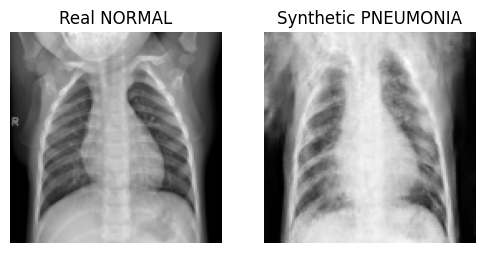

In [ ]:
# Pick any image name from trainA (NORMAL)
import os

sample_normal = os.path.join("/content/dataset_300/trainA", os.listdir("/content/dataset_300/trainA")[0])
show_translation(sample_normal, direction="AtoB")


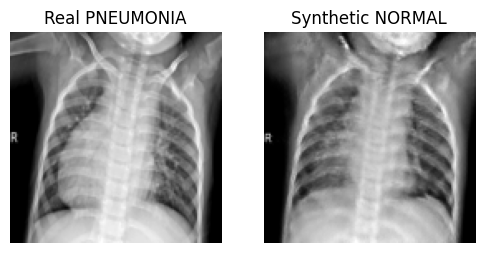

In [ ]:
# Pick any image name from trainB (PNEUMONIA)
sample_pneumonia = os.path.join("/content/dataset_300/trainB", os.listdir("/content/dataset_300/trainB")[0])
show_translation(sample_pneumonia, direction="BtoA")


In [ ]:
torch.save(G_AB.state_dict(), "G_AB_trained.pth")   # Generator Normal → Pneumonia
torch.save(G_BA.state_dict(), "G_BA_trained.pth")   # Generator Pneumonia → Normal
torch.save(D_A.state_dict(), "D_A_trained.pth")     # Discriminator Normal
torch.save(D_B.state_dict(), "D_B_trained.pth")     # Discriminator Pneumonia

print("✅ All models saved successfully.")


✅ All models saved successfully.


In [ ]:
!ls -lh *.pth


-rw-r--r-- 1 root root 11M Nov  5 17:24 D_A_trained.pth
-rw-r--r-- 1 root root 11M Nov  5 17:24 D_B_trained.pth
-rw-r--r-- 1 root root 30M Nov  5 17:24 G_AB_trained.pth
-rw-r--r-- 1 root root 30M Nov  5 17:24 G_BA_trained.pth


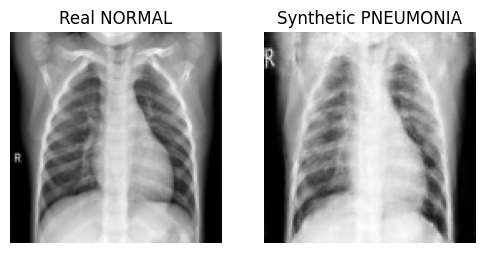

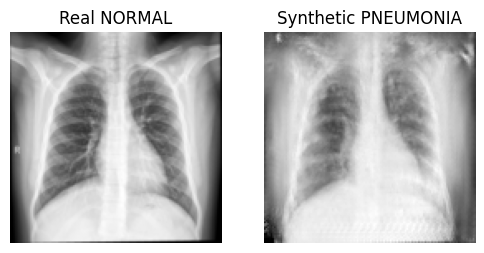

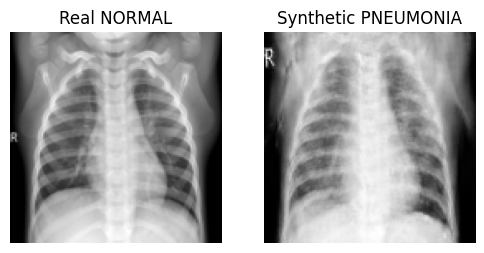

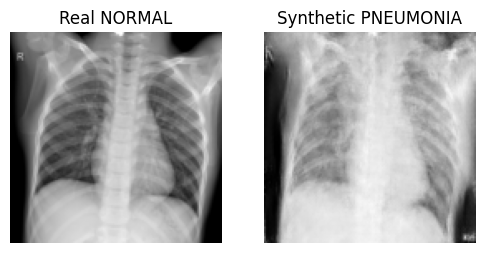

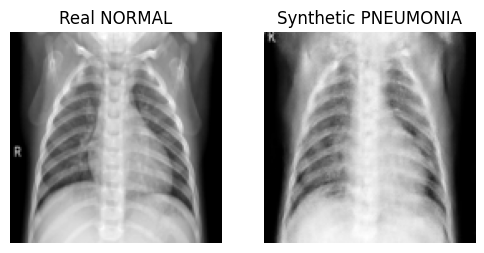

In [ ]:
import random

test_images = random.sample(os.listdir("/content/dataset_300/trainA"), 5)
for img_name in test_images:
    img_path = os.path.join("/content/dataset_300/trainA", img_name)
    show_translation(img_path, direction="AtoB")


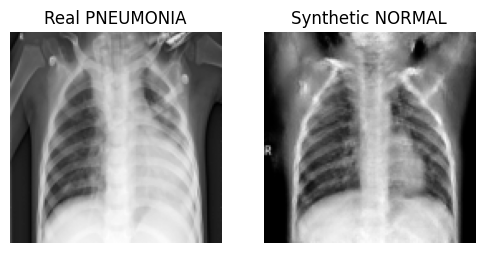

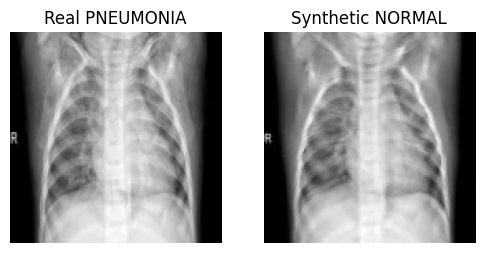

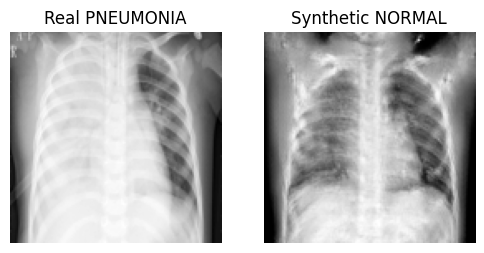

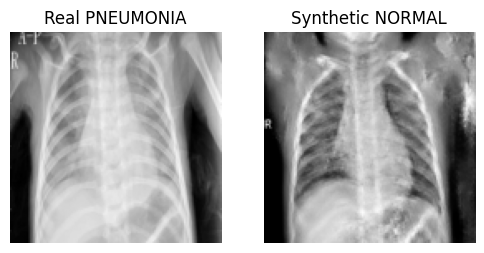

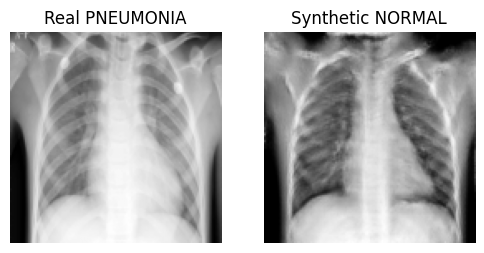

In [ ]:
test_images = random.sample(os.listdir("/content/dataset_300/trainB"), 5)
for img_name in test_images:
    img_path = os.path.join("/content/dataset_300/trainB", img_name)
    show_translation(img_path, direction="BtoA")


In [ ]:
import torchvision.transforms as T
from skimage.metrics import structural_similarity as ssim
from skimage.metrics import peak_signal_noise_ratio as psnr
import numpy as np
from PIL import Image

transform_eval = T.Compose([
    T.Grayscale(),
    T.Resize((256,256)),
    T.ToTensor()
])

def evaluate_translation(G, img_dir, direction="AtoB", num_samples=10):
    ssim_scores, psnr_scores = [], []
    img_list = random.sample(os.listdir(img_dir), num_samples)

    for img_name in img_list:
        img_path = os.path.join(img_dir, img_name)
        img = Image.open(img_path).convert("L")
        inp = transform_eval(img).unsqueeze(0).to(device)

        with torch.no_grad():
            out = G(inp)

        out_img = out.squeeze().cpu().numpy()
        inp_img = inp.squeeze().cpu().numpy()

        # Rescale [-1,1] → [0,1]
        inp_img = (inp_img + 1) / 2
        out_img = (out_img + 1) / 2

        ssim_val = ssim(inp_img, out_img, data_range=1.0)
        psnr_val = psnr(inp_img, out_img, data_range=1.0)
        ssim_scores.append(ssim_val)
        psnr_scores.append(psnr_val)

    print(f"{direction} Translation — Mean SSIM: {np.mean(ssim_scores):.4f}, Mean PSNR: {np.mean(psnr_scores):.2f} dB")

# Evaluate both directions
evaluate_translation(G_AB, "/content/dataset_300/trainA", "AtoB")  # Normal → Pneumonia
evaluate_translation(G_BA, "/content/dataset_300/trainB", "BtoA")  # Pneumonia → Normal


AtoB Translation — Mean SSIM: 0.6961, Mean PSNR: 9.85 dB
BtoA Translation — Mean SSIM: 0.5276, Mean PSNR: 10.16 dB


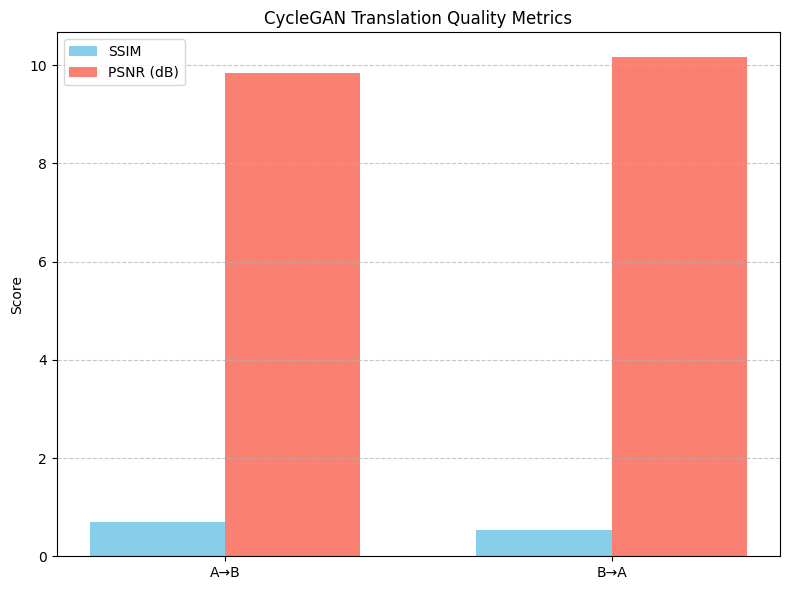

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Values from your results
metrics = ['A→B', 'B→A']
ssim_values = [0.6961, 0.5276]
psnr_values = [9.85, 10.16]

# Create side-by-side bars
x = np.arange(len(metrics))
width = 0.35

plt.figure(figsize=(8,6))
plt.bar(x - width/2, ssim_values, width, label='SSIM', color='skyblue')
plt.bar(x + width/2, psnr_values, width, label='PSNR (dB)', color='salmon')

plt.xticks(x, metrics)
plt.ylabel("Score")
plt.title("CycleGAN Translation Quality Metrics")
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


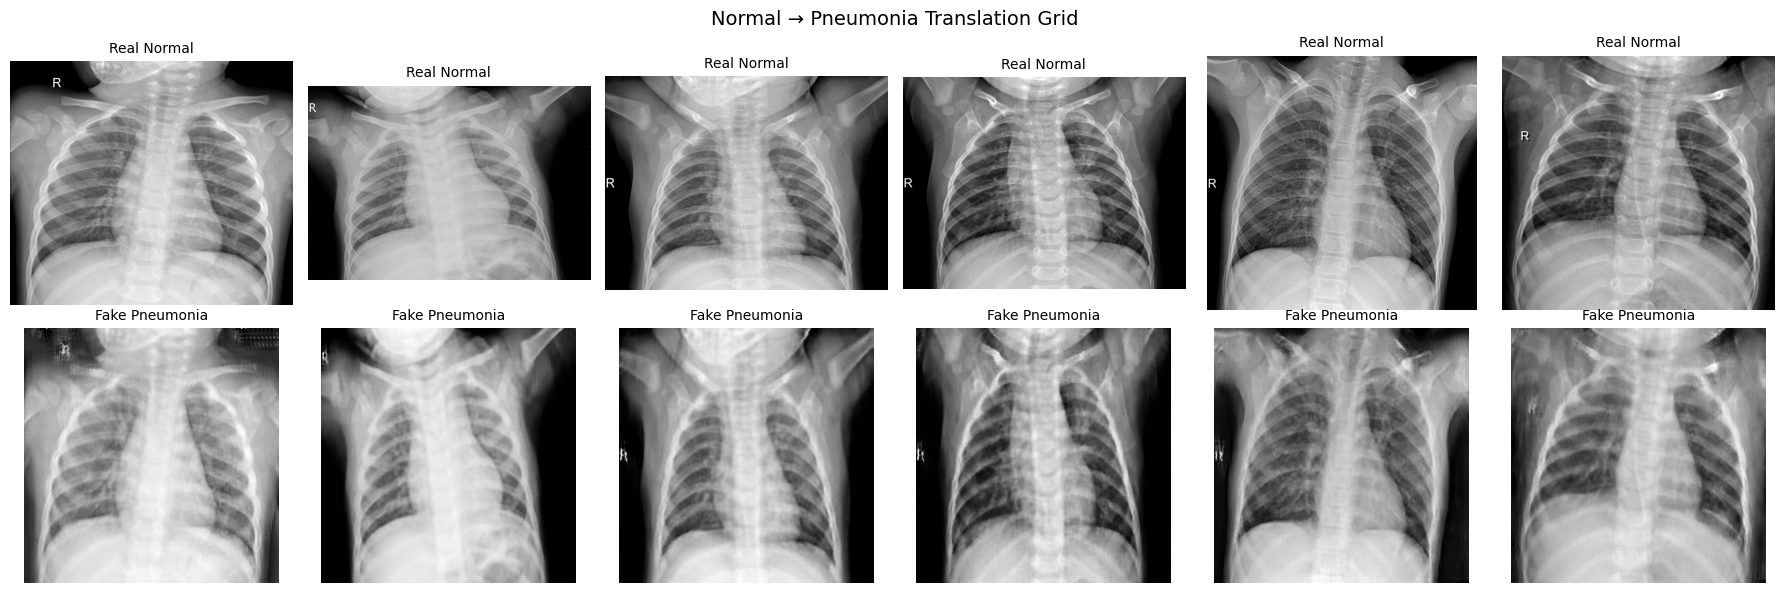

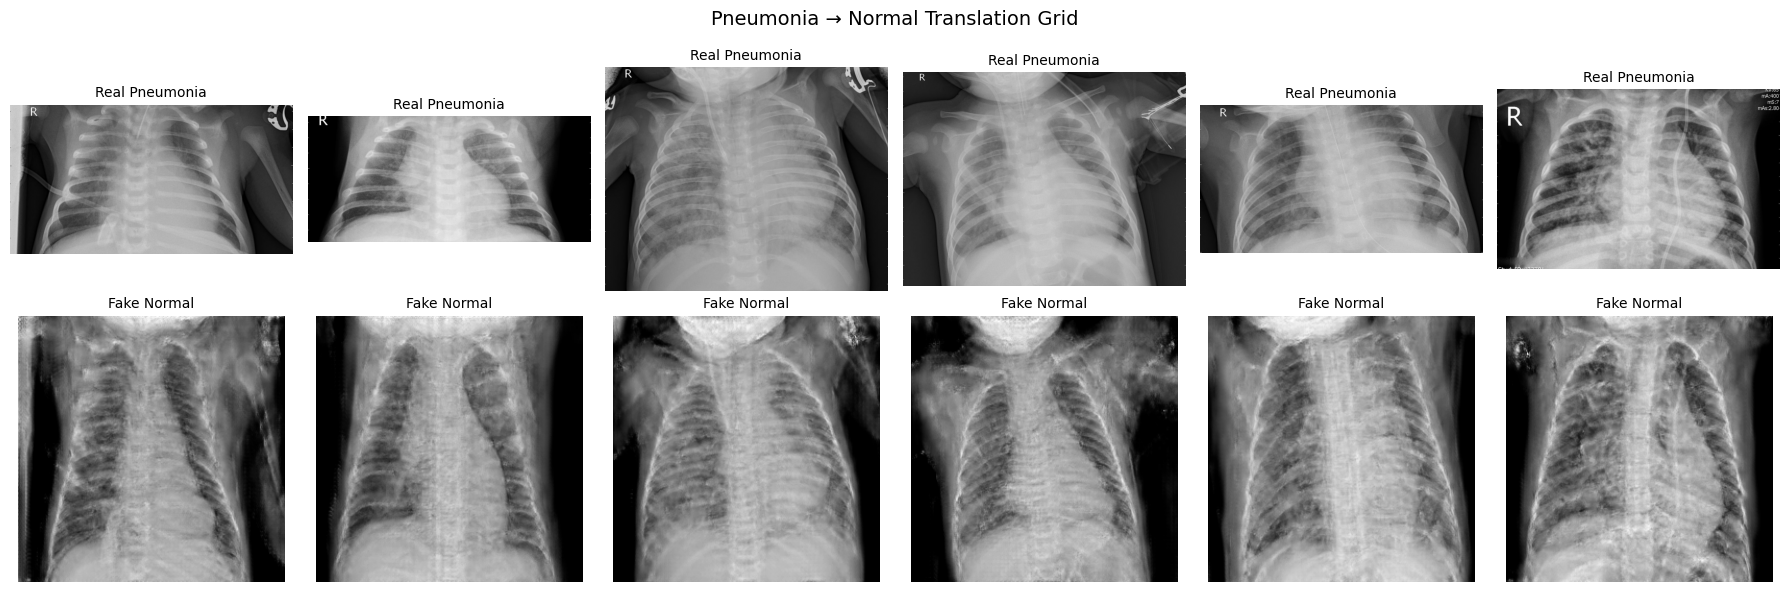

In [ ]:
import matplotlib.pyplot as plt
import torch
from torchvision import transforms
from PIL import Image
import os

# Define paths
path_A = "/content/dataset_300/trainA"   # NORMAL
path_B = "/content/dataset_300/trainB"   # PNEUMONIA

# Transform (same as training)
transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

def load_and_translate(model, img_path):
    img = Image.open(img_path).convert("L")
    img_t = transform(img).unsqueeze(0).to(device)
    with torch.no_grad():
        fake = model(img_t).cpu().squeeze(0)
    fake_img = (fake * 0.5 + 0.5).clamp(0, 1)  # denormalize
    return img, transforms.ToPILImage()(fake_img)

# Select a few random samples
num_samples = 6  # you can increase to 8 or 10 if you want a larger grid
real_As = random.sample(os.listdir(path_A), num_samples)
real_Bs = random.sample(os.listdir(path_B), num_samples)

# Create the grid plot
fig, axes = plt.subplots(2, num_samples, figsize=(3*num_samples, 6))

for i in range(num_samples):
    realA_path = os.path.join(path_A, real_As[i])
    realB_path = os.path.join(path_B, real_Bs[i])

    # A → B (Normal → Pneumonia)
    realA, fakeB = load_and_translate(G_AB, realA_path)
    # B → A (Pneumonia → Normal)
    realB, fakeA = load_and_translate(G_BA, realB_path)

    # Plot top row (A→B)
    axes[0, i].imshow(realA, cmap='gray')
    axes[0, i].set_title("Real Normal", fontsize=10)
    axes[0, i].axis('off')

    axes[1, i].imshow(fakeB, cmap='gray')
    axes[1, i].set_title("Fake Pneumonia", fontsize=10)
    axes[1, i].axis('off')

plt.suptitle("Normal → Pneumonia Translation Grid", fontsize=14)
plt.tight_layout()
plt.show()

# Second grid for Pneumonia → Normal
fig, axes = plt.subplots(2, num_samples, figsize=(3*num_samples, 6))

for i in range(num_samples):
    realB_path = os.path.join(path_B, real_Bs[i])
    realB, fakeA = load_and_translate(G_BA, realB_path)

    axes[0, i].imshow(realB, cmap='gray')
    axes[0, i].set_title("Real Pneumonia", fontsize=10)
    axes[0, i].axis('off')

    axes[1, i].imshow(fakeA, cmap='gray')
    axes[1, i].set_title("Fake Normal", fontsize=10)
    axes[1, i].axis('off')

plt.suptitle("Pneumonia → Normal Translation Grid", fontsize=14)
plt.tight_layout()
plt.show()
